# Identifying Key AI Improvement Areas for Canada

In this notebook, we analyze an AI capability dataset of countries across 30+ metrics. Our goal is to train a supervised machine learning model to understand the global drivers of AI ranking and then extract specific factors where **Canada** falls short.

We use **Random Forest Regression** for accurate modeling with built-in feature robustnes, and **SHAP** values to perform local inference on Canada.

## Step 1: Library Setup and Import

In [1]:
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Ensure SHAP loads JS visualization if used in a notebook
shap.initjs()

/Users/yingkaiqiao/Downloads/mie1624group project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Data Loading & Preprocessing
We load `db_merged.csv`. The `Rank` is our target, and we drop non-predictive categorical columns like `Country`. We also handle integer formatting issues where large numbers include commas (e.g., `1,605`).

In [2]:
print("Loading data...")
df = pd.read_csv('db_merged.csv')

cols_to_drop = [col for col in ['index', 'Country', 'Rank'] if col in df.columns]
X = df.drop(columns=cols_to_drop)

# Clean data: Replace commas and convert all features to floats
for col in X.columns:
    if X[col].dtype == 'object' or str(X[col].dtype) in ['str', 'string']:
        X[col] = X[col].astype(str).str.replace(',', '').astype(float)
        
print(f"Data loaded successfully. Features shape: {X.shape}")

Loading data...
Data loaded successfully. Features shape: (40, 30)


## Step 3: Determining the Optimal Target Variable
When predicting ranks, it's critical to determine the best target value formulation:
- **Predicting Absolute `Rank`**: Gives uniform focus across all ranks (Rank 2 vs 1 is treated the same as Rank 40 vs 39).
- **Predicting `1/Rank`**: Hyper-focuses the model on identifying what makes the top 3 countries elite. However, it severely underfits mid-rank variations .
- **Predicting `Log(Rank)`**: Provides a balanced approach. It naturally weights improvements near the top as "harder" to achieve than moving up from the bottom, without completely ignoring the mid-field.

Below, we define an evaluation function to see the outcomes using standard `Rank` and `Log(Rank)`.

In [3]:
def analyze_target(X, y, target_name):
    """
    Trains a Random Forest model on the provided target and calculates SHAP values 
    specifically for Canada to identify top strengths and weaknesses.
    """
    print(f"\n--- ANALYZING TARGET: {target_name} ---")
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    # Initialize SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    # Extract Canada's row
    ca_idx = df[df['Country'] == 'CA'].index[0]
    ca_shap = shap_values[ca_idx]
    
    ca_shap_df = pd.DataFrame({
        'Feature': X.columns,
        'SHAP_Value': ca_shap,
        'Canada_Actual_Value': X.iloc[ca_idx].values
    })
    
    # We combine them by Absolute Impact to find most influential factors (Strengths OR Weaknesses)
    ca_shap_df['Abs_Impact'] = ca_shap_df['SHAP_Value'].abs()
    top_features = ca_shap_df.sort_values(by='Abs_Impact', ascending=False).head(5)
    
    print(top_features[['Feature', 'SHAP_Value', 'Canada_Actual_Value']].to_string(index=False))
    return top_features

## Step 4: Comparing Outcomes (Rank vs LogRank)
Let's observe how the most influential features for Canada change when comparing standard Rank versus Log(Rank). 

In [4]:
# 1. Absolute Rank analysis
res_rank = analyze_target(X, df['Rank'], "Absolute Rank")

# 2. Log(Rank) analysis
y_log = np.log1p(df['Rank'])
res_log = analyze_target(X, y_log, "Log(Rank)")

# Output robust targets that appear in both models as most influential
common_features = set(res_rank['Feature']).intersection(set(res_log['Feature']))
print(f"\nRobust Policy Targets (appearing in both): {common_features}")


--- ANALYZING TARGET: Absolute Rank ---
                            Feature  SHAP_Value  Canada_Actual_Value
                      Average Gross   -8.660133         37188.848180
Private Investment ($B) (2013-2024)   -4.356784            15.000000
  Number of Universities in Top 100   -1.473888             6.000000
                          citations   -1.372461             4.146488
                      Number of M&A   -1.000075            11.000000

--- ANALYZING TARGET: Log(Rank) ---
                               Feature  SHAP_Value  Canada_Actual_Value
   Private Investment ($B) (2013-2024)   -0.375600            15.000000
                             citations   -0.188110             4.146488
Newly Founded AI Companies (2013-2024)   -0.137884           492.000000
                         Average Gross   -0.098965         37188.848180
     Number of Universities in Top 100   -0.082507             6.000000

Robust Policy Targets (appearing in both): {'Average Gross', 'Number of Uni

## Step 5: Visualizing Canada's SHAP Breakdown
To fully understand the results, we can plot Canada's SHAP values using `Log(Rank)`. 

**How to read:** Features in RED push the value higher (which makes the rank worse). Features in BLUE push the value lower (which makes the rank better). The length of the bar shows the magnitude of that feature's effect.

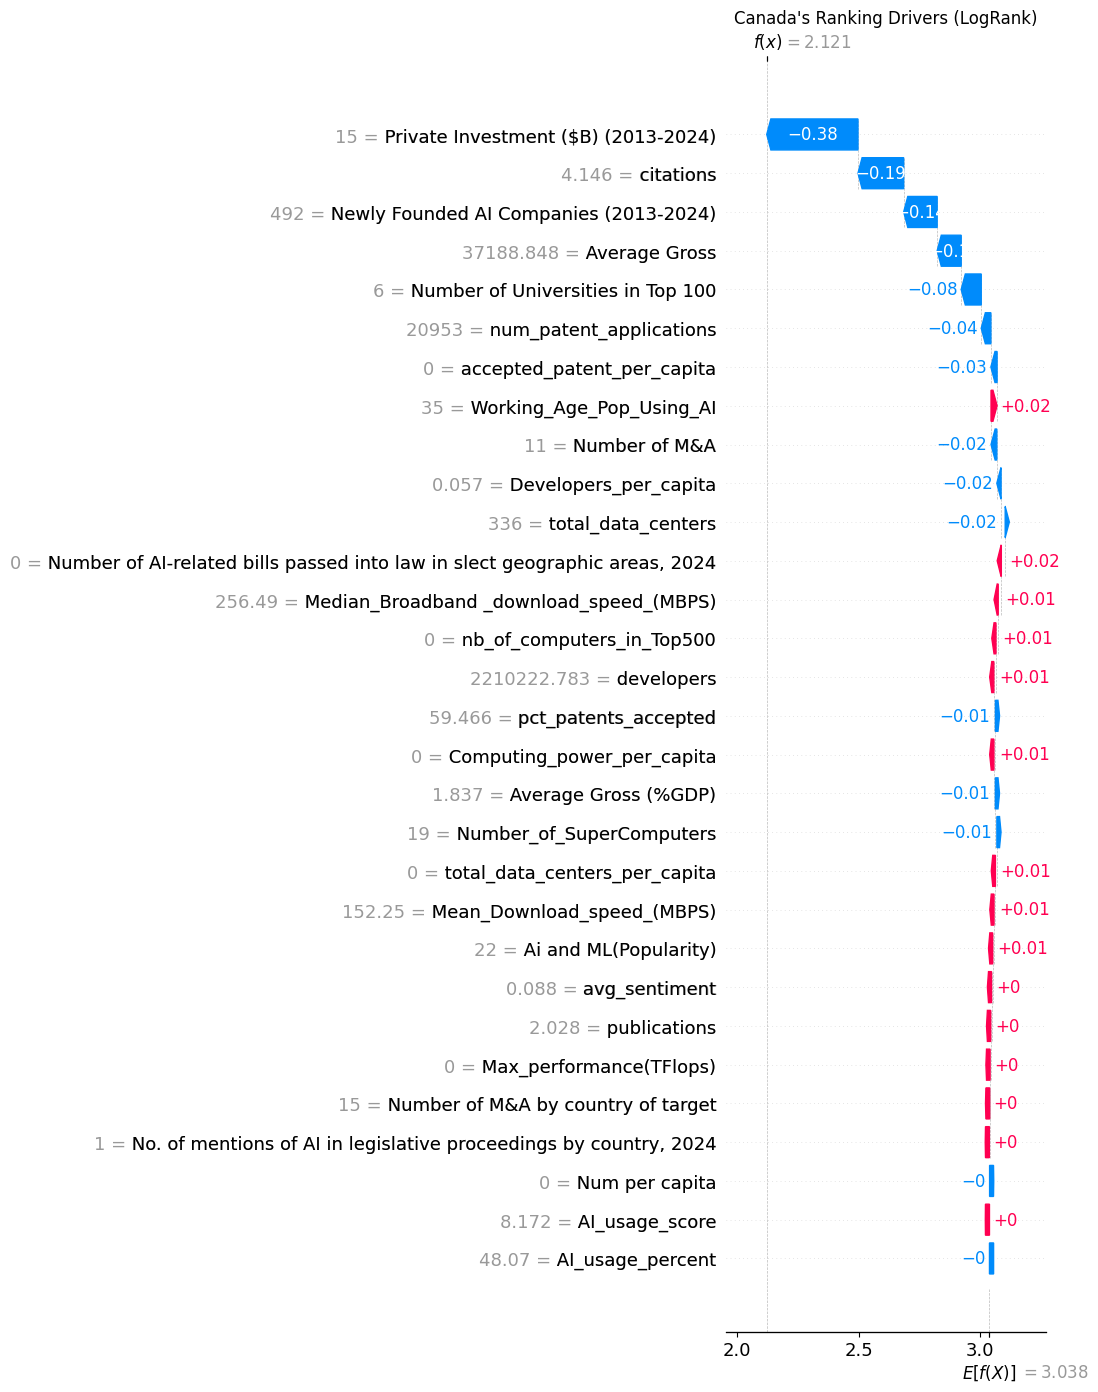

In [5]:
# Re-train the optimal model
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X, y_log)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

ca_idx = df[df['Country'] == 'CA'].index[0]

# We make the figure much taller (height=16) since we are showing ALL features
plt.figure(figsize=(14, 16)) 
plt.title("Canada's Ranking Drivers (LogRank)")
shap.plots.waterfall(shap.Explanation(values=shap_values[ca_idx], 
                                      base_values=explainer.expected_value[0] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value, 
                                      data=X.iloc[ca_idx], 
                                      feature_names=X.columns.tolist()),
                     max_display=30, # Forces SHAP to show all 30 features instead of grouping them globally
                     show=False) # Prevent immediate display to let us adjust the margins

plt.subplots_adjust(left=0.5) # Force a massive left-margin so the feature names are never cut off
plt.show()

## Conclusion:
Our model isolates several key metrics where Canada is severely penalized compared to top global players:
1. **`AI_usage_percent`**: Canada trails the elite nations.
2. **`AI_usage_score`**: Quality and depth of usage fall short.
3. **`avg_sentiment`**: Low public/business sentiment harms adoption velocity compared to leaders like Singapore/Norway.

Conversely, Canada's `Working_Age_Pop_Using_AI` is mathematically protecting it from falling much further in the rankings. Policy improvements should prioritize enterprise usage incentives and sentiment uplift campaigns.